# Sentiment140 Baseline: TF-IDF + Logistic Regression

This notebook implements the TF-IDF + Logistic Regression baseline for the Sentiment140 pipeline with establishing an unified project structure.

It is designed to:
- create fixed 60/10/30 Sentiment140 splits
- train a TF-IDF + Logistic Regression baseline
- save reusable experiment artifacts under the Sentiment140 subfolder
- export publication-ready figures for later thesis writing
- construct a simple example of a **happiness index** through aggregated sentiment scores


## 0. Environment Setup and Dependency Check

This section verifies the core packages required for the baseline experiment. Running it first helps reduce import-related errors and makes the notebook easier to reproduce in a new environment.


In [2]:
import importlib
import subprocess
import sys


def install_if_missing(package_name, import_name=None):
    module_name = import_name or package_name
    try:
        importlib.import_module(module_name)
        print(f"✅ {package_name} already installed")
    except ImportError:
        print(f"⬇️ Installing {package_name}...")
        subprocess.check_call([sys.executable, "-m", "pip", "install", package_name])


required_packages = [
    ("numpy", "numpy"),
    ("pandas", "pandas"),
    ("scikit-learn", "sklearn"),
    ("matplotlib", "matplotlib"),
    ("seaborn", "seaborn"),
    ("joblib", "joblib"),
]

for package_name, import_name in required_packages:
    install_if_missing(package_name, import_name)

print(f"Python executable: {sys.executable}")


✅ numpy already installed
✅ pandas already installed
✅ scikit-learn already installed
✅ matplotlib already installed
✅ seaborn already installed
✅ joblib already installed
Python executable: /opt/anaconda3/envs/happiness-nlp/bin/python


## 1. Load the Sentiment140 Dataset

The raw file contains the standard Sentiment140 fields. For the baseline model, only the original target label and tweet text are used.


In [3]:
import pandas as pd
from pathlib import Path

NOTEBOOK_DIR = Path.cwd()
CODE_DIR = NOTEBOOK_DIR.parent if NOTEBOOK_DIR.name == "notebooks" else NOTEBOOK_DIR
PROJECT_ROOT = CODE_DIR.parent
DATASET_DIR = PROJECT_ROOT / "Dataset" / "sentiment140"
ARTIFACT_DIR = CODE_DIR / "artifacts" / "sentiment140"
CONFIG_DIR = ARTIFACT_DIR / "config"
MODEL_DIR = ARTIFACT_DIR / "models"
PRED_DIR = ARTIFACT_DIR / "predictions"
SPLIT_DIR = ARTIFACT_DIR / "splits"
FIG_DIR = ARTIFACT_DIR / "figures"

for path in [CONFIG_DIR, MODEL_DIR, PRED_DIR, SPLIT_DIR, FIG_DIR]:
    path.mkdir(parents=True, exist_ok=True)

DATA_CANDIDATES = [
    DATASET_DIR / "training.1600000.processed.noemoticon.csv",
]

DATA_PATH = next((path for path in DATA_CANDIDATES if path.exists()), None)
if DATA_PATH is None:
    raise FileNotFoundError(
        "Sentiment140 data file not found. Expected one of: " + ", ".join(str(p) for p in DATA_CANDIDATES)
    )

COLS = ["target", "ids", "date", "flag", "user", "text"]

df = pd.read_csv(
    DATA_PATH,
    encoding="ISO-8859-1",
    header=None,
    names=COLS,
    usecols=["target", "text"],
    dtype={"target": "int32", "text": "string"},
)

# Keep the standard binary labels only: 0 = negative, 4 = positive
df = df[df["target"].isin([0, 4])].copy()
df["label"] = (df["target"] == 4).astype("int8")

print("Loaded from:", DATA_PATH.resolve())
print("Dataset shape:", df.shape)
df.head()


Loaded from: /Users/victor/Desktop/Graduation_Thesis/Dataset/sentiment140/training.1600000.processed.noemoticon.csv
Dataset shape: (1600000, 3)


,target,text,label
0,0,"@switchfoot http://twitpic.com/2y1zl - Awww, t...",0
1,0,is upset that he can't update his Facebook by ...,0
2,0,@Kenichan I dived many times for the ball. Man...,0
3,0,my whole body feels itchy and like its on fire,0
4,0,"@nationwideclass no, it's not behaving at all....",0


## 2. Apply Lightweight, Sentiment-Preserving Preprocessing

The preprocessing keeps useful emotional signals such as negation, repeated characters, hashtags, and punctuation, while removing low-value noise like URLs, mentions, and redundant whitespace.


In [4]:
import re

URL_RE = re.compile(r"(https?://\S+|www\.\S+)")
USER_RE = re.compile(r"@\w+")
HTML_RE = re.compile(r"&\w+;")
# # Remove noisy characters while keeping common sentiment cues such as ! ? # and apostrophes.
BAD_CHARS_RE = re.compile(r"[^0-9A-Za-z\s!?#!'’]")

MULTISPACE_RE = re.compile(r"\s+")
REPEAT_RE = re.compile(r"(.)\1{3,}")  # # Normalize very long character repetitions.

def normalize_repeats(text: str) -> str:
    # Example: soooo -> soo, keeping some intensity information.
    return REPEAT_RE.sub(r"\1\1", text)

def preprocess(text: str) -> str:
    if text is None:
        return ""
    t = str(text)
    t = HTML_RE.sub(" ", t)
    t = URL_RE.sub(" <URL> ", t)
    t = USER_RE.sub(" <USER> ", t)
    t = normalize_repeats(t)
    # Preserve hashtag meaning: #happy -> HASHTAG_happy.
    t = re.sub(r"#(\w+)", r" HASHTAG_\1 ", t)
    # Normalize apostrophes while keeping n't patterns.
    t = t.replace("’", "'")
    t = BAD_CHARS_RE.sub(" ", t)
    t = MULTISPACE_RE.sub(" ", t).strip()
    return t.lower()

df["text_clean"] = df["text"].map(preprocess)

df[["text","text_clean","label"]].head(10)


,text,text_clean,label
0,"@switchfoot http://twitpic.com/2y1zl - Awww, t...",user url awww that's a bummer you shoulda got ...,0
1,is upset that he can't update his Facebook by ...,is upset that he can't update his facebook by ...,0
2,@Kenichan I dived many times for the ball. Man...,user i dived many times for the ball managed t...,0
3,my whole body feels itchy and like its on fire,my whole body feels itchy and like its on fire,0
4,"@nationwideclass no, it's not behaving at all....",user no it's not behaving at all i'm mad why a...,0
5,@Kwesidei not the whole crew,user not the whole crew,0
6,Need a hug,need a hug,0
7,@LOLTrish hey long time no see! Yes.. Rains a...,user hey long time no see! yes rains a bit onl...,0
8,@Tatiana_K nope they didn't have it,user nope they didn't have it,0
9,@twittera que me muera ?,user que me muera ?,0


## 3. Create Fixed 60/10/30 Stratified Splits

The dataset is split into train, validation, and test sets with a fixed random seed. Stratification keeps the positive and negative class ratio stable across all splits.


In [5]:
from sklearn.model_selection import train_test_split

RANDOM_STATE = 42

split_source = df[["text", "text_clean", "label"]].copy()

# First split: 60% train, 40% temporary
train_df, temp_df = train_test_split(
    split_source,
    test_size=0.40,
    random_state=RANDOM_STATE,
    stratify=split_source["label"],
)

# Second split: the temporary 40% becomes 10% validation and 30% test
val_df, test_df = train_test_split(
    temp_df,
    test_size=0.75,
    random_state=RANDOM_STATE,
    stratify=temp_df["label"],
)


def dist(name, frame):
    return name, len(frame), float(frame["label"].mean())

for item in [dist("train", train_df), dist("val", val_df), dist("test", test_df)]:
    print(item)


('train', 960000, 0.5)
('val', 160000, 0.5)
('test', 480000, 0.5)


## 4. Train the TF-IDF + Logistic Regression Baseline

This baseline uses unigram and bigram TF-IDF features together with Logistic Regression. The setup is simple, interpretable, and suitable as a reference model for later comparisons.


In [6]:
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression

tfidf_lr = Pipeline([
    ("tfidf", TfidfVectorizer(
        ngram_range=(1,2),
        min_df=2,
        max_df=0.95,
        sublinear_tf=True,
    )),
    ("clf", LogisticRegression(
        max_iter=200,
        solver="saga",
        n_jobs=-1,
        class_weight="balanced",
        random_state=RANDOM_STATE,
    ))
])

X_train, y_train = train_df["text_clean"], train_df["label"]
X_val, y_val     = val_df["text_clean"],   val_df["label"]
X_test, y_test   = test_df["text_clean"],  test_df["label"]

tfidf_lr.fit(X_train, y_train)

print("val_acc:", tfidf_lr.score(X_val, y_val))
print("test_acc:", tfidf_lr.score(X_test, y_test))


val_acc: 0.8224375
test_acc: 0.8225604166666667


## 5. Evaluate the Baseline Model

The baseline is evaluated on the held-out test split using classification metrics and a Seaborn confusion-matrix heatmap. The figure will be saved to the `artifacts/sentiment140/figures` folder for later thesis writing and result comparison.


              precision    recall  f1-score   support

           0     0.8267    0.8162    0.8214    240000
           1     0.8185    0.8290    0.8237    240000

    accuracy                         0.8226    480000
   macro avg     0.8226    0.8226    0.8226    480000
weighted avg     0.8226    0.8226    0.8226    480000



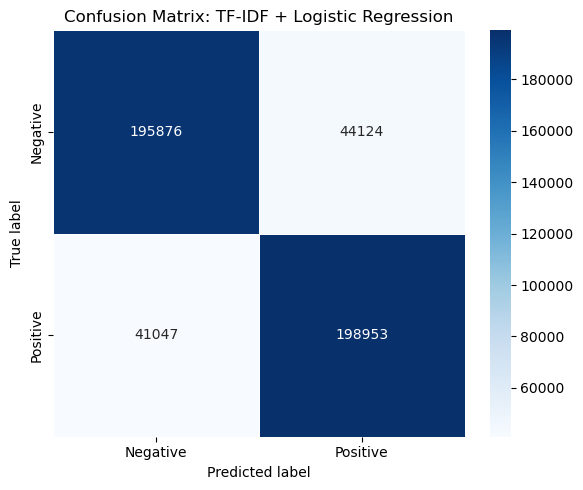

Saved confusion matrix figure to: /Users/victor/Desktop/Graduation_Thesis/Code/artifacts/sentiment140/figures/tfidf_lr_confusion_matrix.png


In [7]:
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

y_pred = tfidf_lr.predict(X_test)

print(classification_report(y_test, y_pred, digits=4))

cm = confusion_matrix(y_test, y_pred)
cm_df = pd.DataFrame(
    cm,
    index=["Negative", "Positive"],
    columns=["Negative", "Positive"],
)

plt.figure(figsize=(6, 5))
ax = sns.heatmap(
    cm_df,
    annot=True,
    fmt="d",
    cmap="Blues",
    cbar=True,
    linewidths=0.5,
    linecolor="white",
)
ax.set_xlabel("Predicted label")
ax.set_ylabel("True label")
ax.set_title("Confusion Matrix: TF-IDF + Logistic Regression")

CM_PATH = FIG_DIR / "tfidf_lr_confusion_matrix.png"
plt.tight_layout()
plt.savefig(CM_PATH, dpi=300, bbox_inches="tight")
plt.show()

print("Saved confusion matrix figure to:", CM_PATH.resolve())


## 6. Save Reusable Artifacts

This section saves the trained pipeline, fixed dataset splits, and a compact experiment configuration. The split files are exported directly from the already-split DataFrames, so the saved schema stays consistent throughout the notebook and no later column backfilling is needed.


In [8]:
import json
import joblib

split_frames = {
    "train_60.csv": train_df[["text", "text_clean", "label"]].copy(),
    "val_10.csv": val_df[["text", "text_clean", "label"]].copy(),
    "test_30.csv": test_df[["text", "text_clean", "label"]].copy(),
}

MODEL_PATH = MODEL_DIR / "tfidf_lr_model.joblib"
CONFIG_PATH = CONFIG_DIR / "tfidf_lr_config.json"

joblib.dump(tfidf_lr, MODEL_PATH)

for filename, frame in split_frames.items():
    frame.to_csv(SPLIT_DIR / filename, index=False)

config_payload = {
    "dataset": "sentiment140",
    "data_path": str(DATA_PATH),
    "random_state": RANDOM_STATE,
    "split_ratio": {"train": 0.60, "val": 0.10, "test": 0.30},
    "split_columns": ["text", "text_clean", "label"],
    "preprocessing": "minimal_cleaning_with_sentiment_signal_preservation",
    "model": {
        "name": "tfidf_logistic_regression",
        "ngram_range": [1, 2],
        "min_df": 2,
        "max_df": 0.95,
        "sublinear_tf": True,
        "max_iter": 200,
        "solver": "saga",
        "class_weight": "balanced",
    },
    "figures": {
        "confusion_matrix": str(FIG_DIR / "tfidf_lr_confusion_matrix.png"),
    },
}

with open(CONFIG_PATH, "w", encoding="utf-8") as f:
    json.dump(config_payload, f, ensure_ascii=False, indent=2)

print("Saved model to:", MODEL_PATH.resolve())
print("Saved splits to:", SPLIT_DIR.resolve())
print("Saved config to:", CONFIG_PATH.resolve())


Saved model to: /Users/victor/Desktop/Graduation_Thesis/Code/artifacts/sentiment140/models/tfidf_lr_model.joblib
Saved splits to: /Users/victor/Desktop/Graduation_Thesis/Code/artifacts/sentiment140/splits
Saved config to: /Users/victor/Desktop/Graduation_Thesis/Code/artifacts/sentiment140/config/tfidf_lr_config.json


## 7. Add a Neutral Band for Inference

Sentiment140 is trained here as a binary dataset. To support later happiness-index style aggregation, a neutral band is added at inference time using probability thresholds rather than retraining a three-class model.


In [ ]:
import numpy as np

# --- Neutral post-hoc mapping ---
NEG_TH = 0.40
POS_TH = 0.60

def proba_to_3class(proba_pos: np.ndarray, neg_th: float = NEG_TH, pos_th: float = POS_TH):
    labels = np.full(shape=proba_pos.shape, fill_value='NEUTRAL', dtype=object)
    labels[proba_pos <= neg_th] = 'NEGATIVE'
    labels[proba_pos >= pos_th] = 'POSITIVE'
    return labels

def predict_sentiment(texts, neg_th: float = NEG_TH, pos_th: float = POS_TH):
    """返回：[(text, P(pos), binary_label, three_class_label), ...]"""
    texts_clean = [preprocess(t) for t in texts]
    proba_pos = tfidf_lr.predict_proba(texts_clean)[:, 1]
    binary_label = (proba_pos >= 0.5).astype(int)
    three_class_label = proba_to_3class(proba_pos, neg_th=neg_th, pos_th=pos_th)
    return list(zip(texts, proba_pos, binary_label, three_class_label))

# demo
examples = [
    'I am sooooo happy!!!',
    'not good at all...',
    'This is fine? maybe.',
]
predict_sentiment(examples)


[('I am sooooo happy!!!', 0.9389208301802631, 1, 'POSITIVE'),
 ('not good at all...', 0.009804492764019956, 0, 'NEGATIVE'),
 ('This is fine? maybe.', 0.85946487137273, 1, 'POSITIVE')]

## 8. Export Test Predictions and Threshold Settings

The binary predictions, three-class inference results, and neutral-threshold configuration are exported for later analysis, reporting, and GUI integration. Because the split schema is fixed earlier in the notebook, the export logic can use the standard `text`, `text_clean`, and `label` columns directly.


In [12]:
import json
import pandas as pd
import numpy as np

# ================
# 1) Save thresholds
# ================
THRESHOLD_PATH = CONFIG_DIR / "tfidf_lr_neutral_thresholds.json"
with open(THRESHOLD_PATH, "w", encoding="utf-8") as f:
    json.dump(
        {
            "neg_th": float(NEG_TH),
            "pos_th": float(POS_TH),
            "policy": "post_hoc_thresholding_on_p_positive",
        },
        f,
        ensure_ascii=False,
        indent=2,
    )

# ==========================
# 2) Predict probabilities
# ==========================
x_test_infer = test_df["text_clean"].astype(str).tolist()
proba_pos_test = tfidf_lr.predict_proba(x_test_infer)[:, 1]
pred_binary_test = (proba_pos_test >= 0.5).astype(int)

# ==========================
# 3) Build binary export df
# ==========================
pred_binary_df = pd.DataFrame(
    {
        "text": test_df["text"].astype(str).tolist(),
        "text_clean": test_df["text_clean"].astype(str).tolist(),
        "y_true": test_df["label"].astype(int).tolist(),
        "proba_pos": proba_pos_test.astype(float),
        "pred_binary": pred_binary_test.astype(int),
    }
)

pred_binary_path = PRED_DIR / "pred_test_tfidf_lr_binary.csv"
pred_binary_df.to_csv(pred_binary_path, index=False, encoding="utf-8")

# ===========================================
# 4) 3-class mapping (Neutral post-processing)
# ===========================================
pred_3class_test = proba_to_3class(proba_pos_test, neg_th=NEG_TH, pos_th=POS_TH)

pred_neutral_df = pred_binary_df.copy()
pred_neutral_df["pred_3class"] = pred_3class_test

pred_neutral_path = PRED_DIR / f"pred_test_tfidf_lr_neutral_{NEG_TH:.2f}_{POS_TH:.2f}.csv"
pred_neutral_df.to_csv(pred_neutral_path, index=False, encoding="utf-8")

# ==========================
# 5) Print summary
# ==========================
print("✅ Saved Neutral thresholds to:", THRESHOLD_PATH.resolve())
print("✅ Saved binary predictions to:", pred_binary_path.resolve())
print("✅ Saved Neutral predictions to:", pred_neutral_path.resolve())

neutral_rate = (pred_neutral_df["pred_3class"] == "NEUTRAL").mean()
print(f"ℹ️ Neutral rate on test set: {neutral_rate:.4f}")


✅ Saved Neutral thresholds to: /Users/victor/Desktop/Graduation_Thesis/Code/artifacts/sentiment140/config/tfidf_lr_neutral_thresholds.json
✅ Saved binary predictions to: /Users/victor/Desktop/Graduation_Thesis/Code/artifacts/sentiment140/predictions/pred_test_tfidf_lr_binary.csv
✅ Saved Neutral predictions to: /Users/victor/Desktop/Graduation_Thesis/Code/artifacts/sentiment140/predictions/pred_test_tfidf_lr_neutral_0.40_0.60.csv
ℹ️ Neutral rate on test set: 0.1285


## 9. Compute a Simple Happiness Index Example

As a small demonstration, the three-class outputs are aggregated into a simple score where positive, neutral, and negative predictions contribute +1, 0, and -1 respectively.


In [ ]:
# --- Happiness Index Example ---
# demo：POS=+1, NEU=0, NEG=-1
def happiness_score_from_3class(labels_3):
    mapping = {'POSITIVE': 1, 'NEUTRAL': 0, 'NEGATIVE': -1}
    vals = np.array([mapping[l] for l in labels_3], dtype=float)
    return vals.mean() if len(vals) else float('nan')

preds = predict_sentiment(examples)
labels3 = [p[3] for p in preds]
labels3, happiness_score_from_3class(labels3)


(['POSITIVE', 'NEGATIVE', 'POSITIVE'], 0.3333333333333333)